## Step 1: Exploratory Data Analysis (EDA)

Load the dataset from the glass sheet, inspect its shape, structure, summary statistics, and check for missing values.

In [1]:
import pandas as pd

# Load dataset
df = pd.read_excel('glass.xlsx', sheet_name='glass')

# Display basic information
print("Dataset Shape:", df.shape)
print("\n--- Column Data Types & Info ---")
print(df.info())

print("\n--- Missing Values ---")
print(df.isnull().sum())

print("\n--- Summary Statistics ---")
print(df.describe().T[['mean', 'std', 'min', '50%', 'max']])

print("\n--- Class Distribution (Target Column 'Type') ---")
print(df['Type'].value_counts().sort_index())

Dataset Shape: (214, 10)

--- Column Data Types & Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 16.8 KB
None

--- Missing Values ---
RI      0
Na      0
Mg      0
Al      0
Si      0
K       0
Ca      0
Ba      0
Fe      0
Type    0
dtype: int64

--- Summary Statistics ---
           mean       std       min       50%       max
RI     1.518365  0.003037   1.51115   1.51768   1.53393
Na    13.407850  0.816604  10.73000  13.30000  17.38000
Mg 

## Step 2: Data Visualization

Plot histograms for feature distributions, boxplots to identify outliers, and a correlation matrix heatmap to check relationships between features.

<Figure size 1200x1000 with 0 Axes>

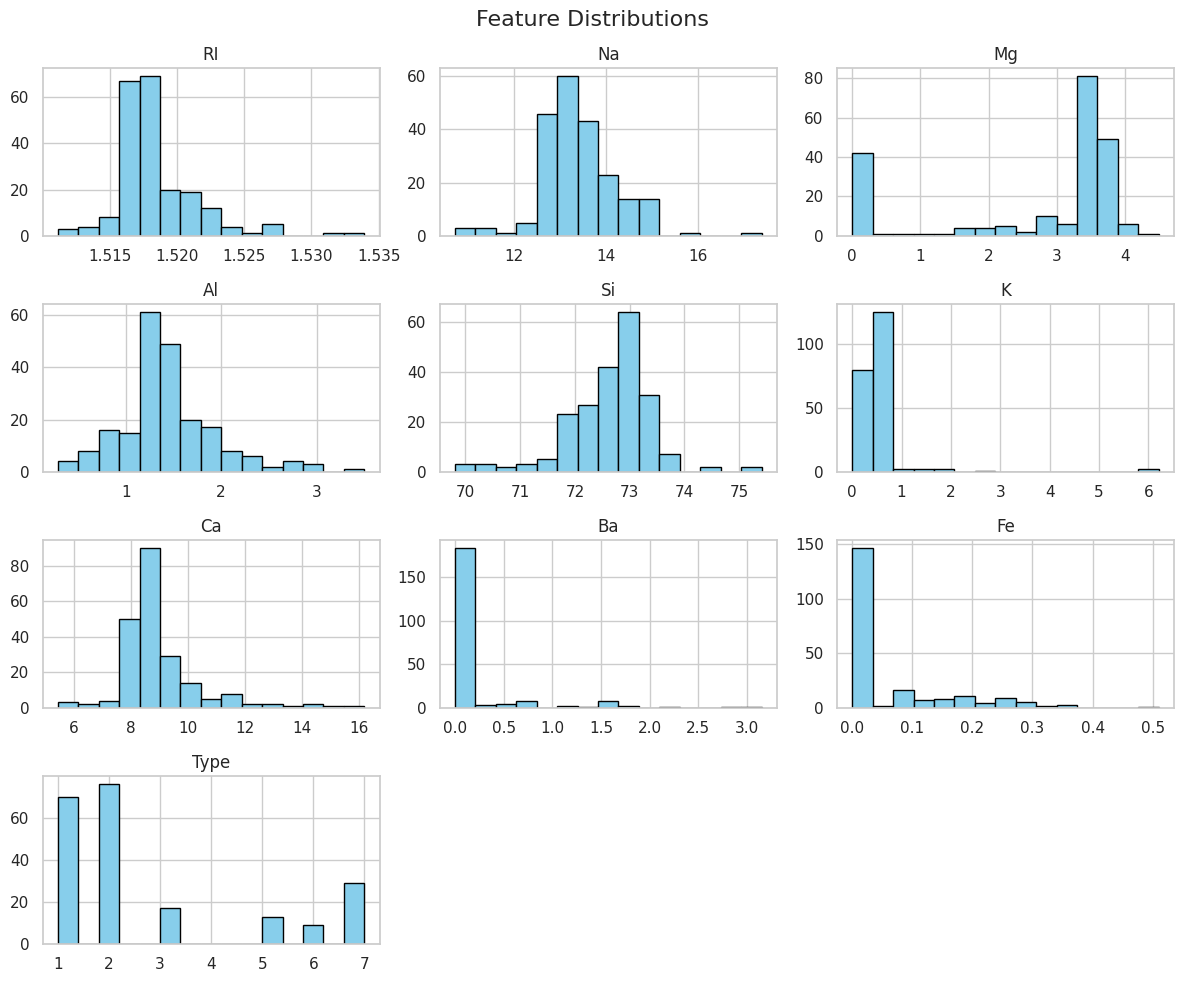

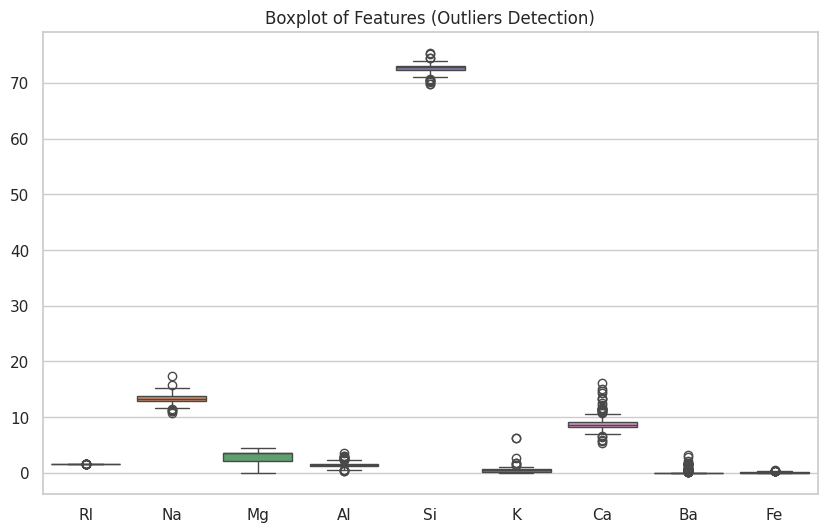

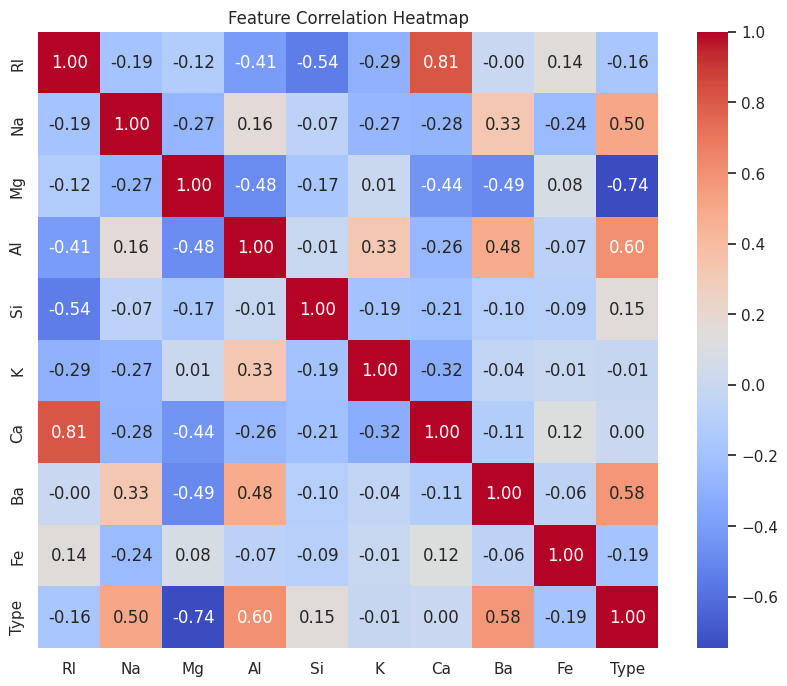

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")

# 1. Histograms for feature distributions
plt.figure(figsize=(12, 10))
df.hist(figsize=(12, 10), bins=15, color='skyblue', edgecolor='black')
plt.suptitle('Feature Distributions', fontsize=16)
plt.tight_layout()
plt.show()

# 2. Box plots for outlier detection
plt.figure(figsize=(10, 6))
sns.boxplot(data=df.drop('Type', axis=1))
plt.title('Boxplot of Features (Outliers Detection)')
plt.show()

# 3. Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Heatmap')
plt.show()

## Step 3: Data Preprocessing

Separate features from the target, scale numerical features using StandardScaler, and prepare the data for handling class imbalance.

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separate features (X) and target (y)
X = df.drop('Type', axis=1)
y = df['Type']

# Train-Test Split (80% Train, 20% Test) with stratify to preserve class proportions
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Preprocessing complete.")
print(f"Train set shape: {X_train_scaled.shape}, Test set shape: {X_test_scaled.shape}")

Preprocessing complete.
Train set shape: (171, 9), Test set shape: (43, 9)


## Step 4: Random Forest Model Implementation

Train a Random Forest Classifier using class_weight='balanced' to handle the dataset's class imbalance and evaluate performance on test data.


In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Initialize and train Random Forest Classifier
rf_model = RandomForestClassifier(random_state=42, class_weight='balanced')
rf_model.fit(X_train_scaled, y_train)

# Predict on test set
y_pred_rf = rf_model.predict(X_test_scaled)

# Evaluate metrics
print("--- Random Forest Evaluation ---")
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf, average='weighted', zero_division=0))
print("Recall   :", recall_score(y_test, y_pred_rf, average='weighted', zero_division=0))
print("F1-Score :", f1_score(y_test, y_pred_rf, average='weighted', zero_division=0))

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred_rf, zero_division=0))

--- Random Forest Evaluation ---
Accuracy : 0.7441860465116279
Precision: 0.7499254621347645
Recall   : 0.7441860465116279
F1-Score : 0.739695962951777

--- Classification Report ---
              precision    recall  f1-score   support

           1       0.69      0.79      0.73        14
           2       0.77      0.67      0.71        15
           3       0.50      0.33      0.40         3
           5       0.75      1.00      0.86         3
           6       0.67      1.00      0.80         2
           7       1.00      0.83      0.91         6

    accuracy                           0.74        43
   macro avg       0.73      0.77      0.74        43
weighted avg       0.75      0.74      0.74        43



## Step 5: Bagging and Boosting Methods

Train Bagging and Boosting (AdaBoost) classifiers on the same dataset and compare performance results against Random Forest.

In [7]:
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier

# Initialize models
bag_model = BaggingClassifier(random_state=42)
boost_model = AdaBoostClassifier(random_state=42)

# Train Bagging
bag_model.fit(X_train_scaled, y_train)
y_pred_bag = bag_model.predict(X_test_scaled)

# Train Boosting
boost_model.fit(X_train_scaled, y_train)
y_pred_boost = boost_model.predict(X_test_scaled)

# Compare results in a DataFrame
results = pd.DataFrame({
    'Model': ['Random Forest', 'Bagging', 'Boosting (AdaBoost)'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_bag),
        accuracy_score(y_test, y_pred_boost)
    ],
    'Precision': [
        precision_score(y_test, y_pred_rf, average='weighted', zero_division=0),
        precision_score(y_test, y_pred_bag, average='weighted', zero_division=0),
        precision_score(y_test, y_pred_boost, average='weighted', zero_division=0)
    ],
    'Recall': [
        recall_score(y_test, y_pred_rf, average='weighted', zero_division=0),
        recall_score(y_test, y_pred_bag, average='weighted', zero_division=0),
        recall_score(y_test, y_pred_boost, average='weighted', zero_division=0)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_rf, average='weighted', zero_division=0),
        f1_score(y_test, y_pred_bag, average='weighted', zero_division=0),
        f1_score(y_test, y_pred_boost, average='weighted', zero_division=0)
    ]
})

print("--- Model Performance Comparison ---")
print(results.to_string(index=False))

--- Model Performance Comparison ---
              Model  Accuracy  Precision   Recall  F1-Score
      Random Forest  0.744186   0.749925 0.744186  0.739696
            Bagging  0.697674   0.704319 0.697674  0.698032
Boosting (AdaBoost)  0.488372   0.534461 0.488372  0.500328


### Additional Notes


## 1. Explain Bagging and Boosting methods. How is it different from each other.

Both Bagging (Bootstrap Aggregating) and Boosting are ensemble learning techniques that combine multiple base models (usually decision trees) to create a stronger predictor.

Bagging (Bootstrap Aggregating)

How it works: Draws multiple random sub-samples (bootstrap samples) from the dataset with replacement. An independent weak model is trained on each sample in parallel.

Aggregation: Predictions are averaged (for regression) or combined via majority vote (for classification).

Primary Objective: Reduces variance and prevents overfitting without increasing bias.

Example: Random Forest, BaggingClassifier.

Boosting

How it works: Builds models sequentially in a step-by-step manner. Each new weak learner focuses on the mistakes made by previous models by assigning higher weights to misclassified samples.

Aggregation: Combines predictions using a weighted sum, where better-performing models hold higher influence.

Primary Objective: Reduces bias and variance, turning weak learners into a strong model.

Example: AdaBoost, Gradient Boosting, XGBoost.

In [9]:
from tabulate import tabulate

# Format and print directly as a grid/markdown table
table = [
    ["Concept", "Builds estimators in parallel on bootstrap samples.", "Builds estimators sequentially to correct errors."],
    ["Primary Objective", "Reduces variance and prevents overfitting.", "Reduces bias and variance."],
    ["Sample Weighting", "All instances have equal weight.", "Misclassified samples get higher weights."],
    ["Aggregation Method", "Majority voting or uniform averaging.", "Weighted average based on model performance."],
    ["Noise Handling", "Robust to noise and outliers.", "Sensitive to noise and outliers."],
    ["Algorithms", "Random Forest, Bagging Classifier", "AdaBoost, Gradient Boosting, XGBoost"]
]

headers = ["Aspect", "Bagging", "Boosting"]

print(tabulate(table, headers=headers, tablefmt="grid"))

+--------------------+-----------------------------------------------------+---------------------------------------------------+
| Aspect             | Bagging                                             | Boosting                                          |
+====================+=====================================================+===================================================+
| Concept            | Builds estimators in parallel on bootstrap samples. | Builds estimators sequentially to correct errors. |
+--------------------+-----------------------------------------------------+---------------------------------------------------+
| Primary Objective  | Reduces variance and prevents overfitting.          | Reduces bias and variance.                        |
+--------------------+-----------------------------------------------------+---------------------------------------------------+
| Sample Weighting   | All instances have equal weight.                    | Misclassified sample

## 2. Explain how to handle imbalance in the data.

Cost-Sensitive Learning: Applying class_weight='balanced' penalizes misclassification of underrepresented classes inversely proportional to class frequencies.

Resampling Techniques: Using techniques like SMOTE (Synthetic Minority Over-sampling Technique) to generate synthetic samples for underrepresented classes or random undersampling on dominant classes.

Appropriate Metrics: Evaluating performance using F1-Score, Precision, and Recall rather than plain Accuracy alone.